In [1]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
#Импорты
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor
import os
from itertools import product
from scipy.stats import skew
from scipy.stats import pearsonr, normaltest
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

In [30]:
os.chdir('..')  # перейти в корень проекта
#Загрузка данных
train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
sub   = pd.read_csv("data/sample_submission.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/train.csv'

In [4]:
#Первичный анализ
train.head(5)

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train.describe()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,375.000000,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,216.939316,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,187.500000,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,375.000000,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,562.500000,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,750.000000,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [7]:
train.columns

Index(['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=214)

In [8]:
print("Пропусков: ", train.isna().sum().sum())

Пропусков:  24


Из первичного анализа тренировочного датасета видно, что данные представлены исключительно числовыми значениями.
Причем некоторые признаки представлены чисто 0 и 1 (уже закодированные категориальные признаки).

Пропусков в данных 24 / (751*214), что меньше 1% - такими пропусками можно пренебречь.

In [9]:
X_train = train.drop(['index', 'IC50, mM', 'CC50, mM', 'SI'], axis=1)

y_ic50 = train['IC50, mM'].values.astype(np.float64)
y_cc50 = train['CC50, mM'].values.astype(np.float64)
y_si   = train['SI'].values.astype(np.float64)

In [10]:
var_series = X_train.var().sort_values()
print("Признаки с низкой дисперсией (< 0.001):")
print(var_series[var_series < 0.001])

Признаки с низкой дисперсией (< 0.001):
NumRadicalElectrons    0.0
SMR_VSA8               0.0
SlogP_VSA9             0.0
fr_thiocyan            0.0
fr_phos_acid           0.0
fr_isothiocyan         0.0
fr_nitroso             0.0
fr_lactam              0.0
fr_benzodiazepine      0.0
fr_diazo               0.0
fr_dihydropyridine     0.0
fr_isocyan             0.0
fr_SH                  0.0
fr_barbitur            0.0
fr_azide               0.0
fr_N_O                 0.0
fr_prisulfonamd        0.0
fr_phos_ester          0.0
dtype: float64


Эти признаки имеют очень низкую вариативность и не дадут значимости для модели - можно удалить.

Бинарные fr_* признаки с редкими фрагментами тоже попадают сюда, но их вклад минимален - в будущем можно рассмотреть их и добавить для улучшения точности модели.

In [11]:
corr_list = []
for c in X_train.columns:
    r1 = abs(stats.spearmanr(X_train[c], y_ic50)[0])
    r2 = abs(stats.spearmanr(X_train[c], y_cc50)[0])
    r3 = abs(stats.spearmanr(X_train[c], y_si)[0])
    corr_list.append((c, max(r1, r2, r3)))

corr_df = pd.DataFrame(corr_list, columns=["признак", "макс_корреляция"])
corr_df = corr_df.sort_values("макс_корреляция", ascending=False)

print("Топ-12 признаков:")
print(corr_df.head(12))

Топ-12 признаков:
                      признак  макс_корреляция
45                     Kappa3         0.292102
44                     Kappa2         0.291328
43                     Kappa1         0.284115
120  NumSaturatedHeterocycles         0.281584
9         NumValenceElectrons         0.269125
29                       Chi0         0.268556
16           FpDensityMorgan2         0.267919
124                     MolMR         0.266274
30                      Chi0n         0.265090
31                      Chi0v         0.262846
46                  LabuteASA         0.262113
15           FpDensityMorgan1         0.260579


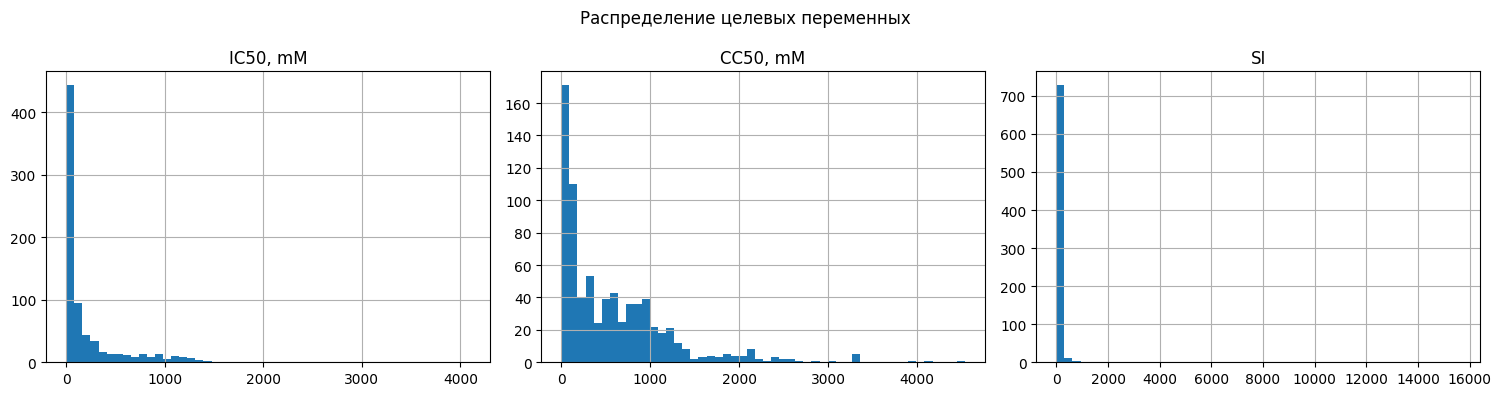

In [12]:
# Распределение целевых переменных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['IC50, mM'].hist(ax=axes[0], bins=50)
axes[0].set_title('IC50, mM')

train['CC50, mM'].hist(ax=axes[1], bins=50)
axes[1].set_title('CC50, mM')

train['SI'].hist(ax=axes[2], bins=50)
axes[2].set_title('SI')

plt.suptitle('Распределение целевых переменных')
plt.tight_layout()
plt.show()

Видно что все три целевых переменных имеют правостороннее распределение с выбросами. Предлагаю обработать их по 99% перцентелю с преобразованием в корень - это даст меньший разброс данных и большую точность модели.

In [ ]:
#Обработка выбросов в целевых переменных
y_ic50_raw = train['IC50, mM'].values.astype(np.float64)
y_cc50_raw = train['CC50, mM'].values.astype(np.float64)
y_si_raw   = train['SI'].values.astype(np.float64)

y_ic50 = np.sqrt(y_ic50_raw)      # квадратный корень
y_cc50 = np.sqrt(y_cc50_raw)      # квадратный корень
y_si   = np.log1p(y_si_raw)       # логарифмическая трансформация


In [14]:
# Удаляем признаки с низкой дисперсией
var_series = X_train.var().sort_values()
X_train = X_train.drop(var_series[var_series < 0.001].index.tolist(), axis=1)

In [15]:
# Feature engineering — логарифмы и отношения признаков
feat_base = X_train.columns.tolist()

for c in feat_base:
    if X_train[c].min() > 0:
        X_train[f"log_{c}"] = np.log1p(X_train[c])
        test[f"log_{c}"]    = np.log1p(test[c])

top12 = feat_base[:12]
for i in range(len(top12)):
    for j in range(i+1, len(top12)):
        X_train[f"r_{i}_{j}"] = X_train[top12[i]] / (X_train[top12[j]] + 1e-8)
        test[f"r_{i}_{j}"]    = test[top12[i]]    / (test[top12[j]]    + 1e-8)

print(f"Итоговых признаков: {X_train.shape[1]}")

X      = np.nan_to_num(X_train.values.astype(np.float64), nan=0, posinf=0, neginf=0)
X_test = np.nan_to_num(test[X_train.columns].values.astype(np.float64), nan=0, posinf=0, neginf=0)

Итоговых признаков: 299


In [ ]:

# ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ CATBOOST С OPTUNA

def objective(trial, X, y, cv_folds=3):
    """
    Целевая функция для Optuna
    """
    
    # Предлагаемые гиперпараметры
    params = {
        'iterations': trial.suggest_int('iterations', 1000, 4000, step=500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 30),
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 200,
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'use_best_model': True,
    }
    
    # Кросс-валидация
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = []
    
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            verbose=False
        )
        
        pred = model.predict(X_val)
        score = np.sqrt(mean_squared_error(y_val, pred))
        scores.append(score)
    
    return np.mean(scores)

# ОПТИМИЗАЦИЯ ДЛЯ КАЖДОГО ТАРГЕТА ОТДЕЛЬНО

def optimize_target(X, y, target_name, n_trials=50):

    print(f"\n{'='*60}")
    print(f"ОПТИМИЗАЦИЯ ДЛЯ {target_name}")
    print(f"{'='*60}")
    
    # Создаем исследование
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=20)
    )
    
    # Запускаем оптимизацию
    study.optimize(
        lambda trial: objective(trial, X, y, cv_folds=3),
        n_trials=n_trials,
        show_progress_bar=True
    )
    
    # Выводим лучшие параметры
    print(f"\nЛучшие параметры для {target_name}:")
    print(f"   Score: {study.best_value:.4f}")
    print(f"   Params:")
    for key, value in study.best_params.items():
        print(f"      {key}: {value}")
    
    return study.best_params, study.best_value

# Запускаем оптимизацию для каждого таргета
print("Начинаем оптимизацию гиперпараметров...")

best_params_ic50, best_score_ic50 = optimize_target(X, y_ic50, "IC50", n_trials=30)
best_params_cc50, best_score_cc50 = optimize_target(X, y_cc50, "CC50", n_trials=30)
best_params_si, best_score_si = optimize_target(X, y_si, "SI", n_trials=30)

[I 2026-05-22 01:08:57,071] A new study created in memory with name: no-name-de8f4f66-e695-4f3a-bc9a-a48a207986d9


Начинаем оптимизацию гиперпараметров...
Это может занять 30-60 минут...

ОПТИМИЗАЦИЯ ДЛЯ IC50


Best trial: 0. Best value: 8.00213:   3%|▎         | 1/30 [00:13<06:42, 13.89s/it]

[I 2026-05-22 01:09:10,962] Trial 0 finished with value: 8.002127287122152 and parameters: {'iterations': 2000, 'learning_rate': 0.044635901521768134, 'depth': 7, 'l2_leaf_reg': 6, 'subsample': 0.6468055921327309, 'min_data_in_leaf': 9}. Best is trial 0 with value: 8.002127287122152.


Best trial: 1. Best value: 7.97672:   7%|▋         | 2/30 [00:23<05:13, 11.20s/it]

...

[I 2026-05-22 01:46:55,533] Trial 27 finished with value: 1.248913535357377 and parameters: {'iterations': 2500, 'learning_rate': 0.006039649378741402, 'depth': 6, 'l2_leaf_reg': 5, 'subsample': 0.7634710210618425, 'min_data_in_leaf': 27}. Best is trial 21 with value: 1.2449302584342623.


Best trial: 21. Best value: 1.24493:  97%|█████████▋| 29/30 [19:44<00:50, 50.68s/it]

[I 2026-05-22 01:47:55,677] Trial 28 finished with value: 1.2481318631806564 and parameters: {'iterations': 1500, 'learning_rate': 0.013788246279518877, 'depth': 8, 'l2_leaf_reg': 7, 'subsample': 0.8458815915159483, 'min_data_in_leaf': 28}. Best is trial 21 with value: 1.2449302584342623.


Best trial: 21. Best value: 1.24493: 100%|██████████| 30/30 [20:10<00:00, 40.34s/it]

[I 2026-05-22 01:48:21,716] Trial 29 finished with value: 1.2467035714730377 and parameters: {'iterations': 3500, 'learning_rate': 0.020905492727615185, 'depth': 7, 'l2_leaf_reg': 6, 'subsample': 0.8897512292863041, 'min_data_in_leaf': 12}. Best is trial 21 with value: 1.2449302584342623.

✅ Лучшие параметры для SI:
   Score: 1.2449
   Params:
      iterations: 3000
      learning_rate: 0.010490175072392808
      depth: 7
      l2_leaf_reg: 8
      subsample: 0.8340472492120019
      min_data_in_leaf: 21


In [ ]:
# Оптимизированные параметры для каждого таргета

# Параметры для IC50
cat_p_ic50 = {
    'iterations': 1500,
    'learning_rate': 0.04935,
    'depth': 6,
    'l2_leaf_reg': 8,
    'subsample': 0.6538,
    'min_data_in_leaf': 23,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 200,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'use_best_model': True,
}

# Параметры для CC50
cat_p_cc50 = {
    'iterations': 3000,
    'learning_rate': 0.01621,
    'depth': 7,
    'l2_leaf_reg': 1,
    'subsample': 0.7138,
    'min_data_in_leaf': 12,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 200,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'use_best_model': True,
}

# Параметры для SI
cat_p_si = {
    'iterations': 3000,
    'learning_rate': 0.01049,
    'depth': 7,
    'l2_leaf_reg': 8,
    'subsample': 0.8340,
    'min_data_in_leaf': 21,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 200,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'use_best_model': True,
}

In [26]:
#Отдельная функция для краткости кода ниже
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [27]:
#Обучение и кросс-валидация
N = 5
kf = KFold(n_splits=N, shuffle=True, random_state=42)

oof_ic50 = np.zeros(len(X))
oof_cc50 = np.zeros(len(X))
oof_si   = np.zeros(len(X))

pred_ic50_trans = np.zeros(len(X_test))
pred_cc50_trans = np.zeros(len(X_test))
pred_si_trans   = np.zeros(len(X_test))

for fold, (tr, val) in enumerate(kf.split(X), 1):
    print(f"Fold {fold}/{N}")
    Xtr, Xval = X[tr], X[val]

    m_ic50 = CatBoostRegressor(**cat_p_ic50)
    m_ic50.fit(Xtr, y_ic50[tr], eval_set=(Xval, y_ic50[val]), use_best_model=True)
    pred_ic50_trans += m_ic50.predict(X_test) / N
    oof_ic50[val] = m_ic50.predict(Xval)

    m_cc50 = CatBoostRegressor(**cat_p_cc50)
    m_cc50.fit(Xtr, y_cc50[tr], eval_set=(Xval, y_cc50[val]), use_best_model=True)
    pred_cc50_trans += m_cc50.predict(X_test) / N
    oof_cc50[val] = m_cc50.predict(Xval)

    m_si = CatBoostRegressor(**cat_p_si)
    m_si.fit(Xtr, y_si[tr], eval_set=(Xval, y_si[val]), use_best_model=True)
    pred_si_trans += m_si.predict(X_test) / N
    oof_si[val] = m_si.predict(Xval)

    r_ic = rmse(y_ic50_raw[val], np.clip(oof_ic50[val], 0, None) ** 2)
    r_cc = rmse(y_cc50_raw[val], np.clip(oof_cc50[val], 0, None) ** 2)
    r_si = rmse(y_si_raw[val], np.expm1(np.clip(oof_si[val], 0, None)))
    print(f"  IC50={r_ic:.1f}  CC50={r_cc:.1f}  SI={r_si:.1f}  mean={((r_ic+r_cc+r_si)/3):.1f}")

Fold 1/5
0:	learn: 9.6002767	test: 9.8627015	best: 9.8627015 (0)	total: 6.5ms	remaining: 9.75s
100:	learn: 6.5058506	test: 8.7248077	best: 8.7248077 (100)	total: 568ms	remaining: 7.87s
200:	learn: 5.4135179	test: 8.7149119	best: 8.6755762 (118)	total: 1.07s	remaining: 6.94s
300:	learn: 4.7467077	test: 8.6595266	best: 8.6532612 (287)	total: 1.61s	remaining: 6.42s
400:	learn: 4.2233860	test: 8.6570046	best: 8.6408257 (335)	total: 2.12s	remaining: 5.81s
500:	learn: 3.8369892	test: 8.6749279	best: 8.6408257 (335)	total: 2.62s	remaining: 5.22s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 8.640825706
bestIteration = 335

Shrink model to first 336 iterations.
0:	learn: 12.7263758	test: 11.7528201	best: 11.7528201 (0)	total: 10.9ms	remaining: 32.7s
100:	learn: 8.7282117	test: 9.5876537	best: 9.5876537 (100)	total: 963ms	remaining: 27.6s
200:	learn: 7.2555841	test: 8.9943226	best: 8.9943226 (200)	total: 1.85s	remaining: 25.8s
300:	learn: 6.4717269	test: 8.8010743	best: 8.8

In [28]:
print("Итоговый RMSE")
r_ic = rmse(y_ic50_raw, np.clip(oof_ic50, 0, None) ** 2)
r_cc = rmse(y_cc50_raw, np.clip(oof_cc50, 0, None) ** 2)
r_si = rmse(y_si_raw, np.expm1(np.clip(oof_si, 0, None)))
print(f"  IC50={r_ic:.1f}  CC50={r_cc:.1f}  SI={r_si:.1f}  mean={((r_ic+r_cc+r_si)/3):.1f}")

Итоговый RMSE
  IC50=322.8  CC50=461.2  SI=782.3  mean=522.1


In [ ]:
# Предсказание
t_ic50 = np.clip(pred_ic50_trans, 0, None) ** 2
t_cc50 = np.clip(pred_cc50_trans, 0, None) ** 2
t_si   = np.expm1(np.clip(pred_si_trans, 0, None))

submission = pd.DataFrame({
    "index": test["index"],
    "IC50": t_ic50,
    "CC50": t_cc50,
    "SI": t_si
})

submission.to_csv("submissionv14.csv", index=False)